# Mouse Metrics

## Load Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

## Load / Prepare data

In [2]:
# Load data
hovers = pd.read_csv("/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/mouse_hovers.csv")
events = pd.read_csv("/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/mouse_events_norm.csv")
df = pd.read_csv("/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/participants.csv")

In [3]:
# Merge Condition to Events and Hovers
events = events.merge(df[["participant_id","interest"]], on="participant_id", how="inner")
hovers = hovers.merge(df[["participant_id","interest"]], on="participant_id", how="inner")

## Velocity + Distance

In [4]:
# Grouping by pariticpant id
GROUPING = ("participant_id",)

# Velocity function
def compute_velocity_from_df(events: pd.DataFrame,
                             group_cols=GROUPING,
                             x_col: str = "x_norm",
                             y_col: str = "y_norm") -> tuple[pd.DataFrame, pd.DataFrame]:
    required = {"participant_id", "t_ms", x_col, y_col}
    missing = required - set(events.columns)
    if missing:
        raise ValueError(f"events is missing required columns: {missing}")

    # Copy
    df = events.copy()

    # Ensure numeric types
    df["t_ms"] = pd.to_numeric(df["t_ms"], errors="coerce")
    df[x_col]  = pd.to_numeric(df[x_col], errors="coerce")
    df[y_col]  = pd.to_numeric(df[y_col], errors="coerce")

    # Drop unusable rows
    df = df.dropna(subset=["participant_id", "t_ms", x_col, y_col])

    # Sort within groups by time
    sort_cols = list(group_cols) + ["t_ms"]
    df = df.sort_values(sort_cols)

    # Compute deltas per group
    def _deltas(g: pd.DataFrame) -> pd.DataFrame:
        g = g.copy()
        g["dx"] = g[x_col].diff()
        g["dy"] = g[y_col].diff()
        g["dt_ms"] = g["t_ms"].diff()

        # Euclidean distance
        g["dist_norm"] = np.sqrt(g["dx"]**2 + g["dy"]**2)

        g["dt_s"] = g["dt_ms"] / 1000.0  # in seconds

        # guard against zero/negative/NaN intervals
        bad_dt = ~np.isfinite(g["dt_s"]) | (g["dt_s"] <= 0)
        g.loc[bad_dt, ["dt_s", "dist_norm", "dx", "dy"]] = np.nan

        # velocity per segment
        g["velocity_norm_s"] = g["dist_norm"] / g["dt_s"]
        return g

    df_steps = (
        df.groupby(list(group_cols), dropna=False, as_index=False, group_keys=False)
          .apply(_deltas)
    )

    # Keep only valid step rows for aggregation (the first in each group will be NaN)
    valid = df_steps.dropna(subset=["dist_norm", "dt_s", "velocity_norm_s"]).copy()


    if valid.empty:
        empty_cols = list(group_cols) + [
            "total_distance_norm", "max_velocity_norm_s", "min_velocity_norm_s",
            "mean_velocity_norm_s", "std_velocity_norm_s", "mean_abs_dx", "mean_abs_dy", "n_steps"
        ]
        metrics = pd.DataFrame(columns=empty_cols)
        return metrics, df_steps

    grouped = valid.groupby(list(group_cols), dropna=False)

    metrics = grouped.agg(
        total_distance_norm = ("dist_norm", "sum"),
        max_velocity_norm_s = ("velocity_norm_s", "max"),
        min_velocity_norm_s = ("velocity_norm_s", "min"),
        mean_velocity_norm_s = ("velocity_norm_s", "mean"),
        std_velocity_norm_s = ("velocity_norm_s", "std"),
        n_steps             = ("velocity_norm_s", "count"),
    ).reset_index()

    # For groups with only one valid step, std is NaN → set to 0.0
    metrics["std_velocity_norm_s"] = metrics["std_velocity_norm_s"].fillna(0.0)

    return metrics, df_steps


#  Calculate it from existing events 
metrics, events_with_steps = compute_velocity_from_df(events, group_cols=GROUPING)

# Output
metrics

/var/folders/v_/5q_t13ds7pz7yhp0h3fhnrr40000gn/T/ipykernel_1487/2239408827.py:51: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_deltas)


,participant_id,total_distance_norm,max_velocity_norm_s,min_velocity_norm_s,mean_velocity_norm_s,std_velocity_norm_s,n_steps
0,01caf55c-3693-4aa3-bac2-862230173a5e,125.917601,51.886207,0.0,0.638233,2.932887,4889
1,01f97700-9c92-4464-9bf8-21132acaa881,49.759314,46.165177,0.0,0.745145,2.985198,1423
2,05bcca80-e838-4ef3-8ba8-39e870310e8f,26.969958,56.396576,0.0,0.526646,2.916134,1282
3,09836b97-00f6-47f3-b9aa-c34ad5867121,48.516545,61.207525,0.0,1.003922,4.438613,1034
4,0c8e7770-1c3e-40d4-af3e-561d63ec9aa3,41.415801,64.246638,0.0,1.293324,4.685088,788
...,...,...,...,...,...,...,...
101,f8350255-0cb7-49ec-a1ed-f6d608da537a,98.855516,59.363813,0.0,1.328856,4.837912,1565
102,f848edac-87b3-458d-8ccc-7759502a11c9,36.562241,65.476617,0.0,1.147435,4.303607,783
103,f97814c0-fdd1-4911-ae4f-aa1459d6fa5b,61.267802,62.664810,0.0,1.480402,5.824690,1019
104,fc278ad6-5094-4033-8af8-1a9f63a49278,20.252124,67.235933,0.0,1.085675,3.942067,484


In [5]:
# Save velocity metrics to CSV
velocity_metrics_path = "/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/velocity_metrics_norm.csv" 
metrics.to_csv(velocity_metrics_path, index=False)

print(f"Saved velocity metrics to: {velocity_metrics_path}")

Saved velocity metrics to: /Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/velocity_metrics_norm.csv


## Submovements + Deviation

In [6]:
##################### Parameters #####################

# Peak detection hyperparameters (tuned below)
ROLL_WIN_SAMPLES         = 5
MIN_PROMINENCE_NORM_S    = 0.6
MIN_PEAK_HEIGHT_NORM_S   = 0.7
MIN_PEAK_DISTANCE_MS     = 200

##################### Helper Functions #####################

# Centered moving average
def _moving_avg(a: np.ndarray, win: int) -> np.ndarray:
    if win <= 1:
        return a
    return (
        pd.Series(a, dtype="float64")
        .rolling(win, center=True, min_periods=1)
        .mean()
        .to_numpy()
    )

# Velocity in normalized units per second
def _compute_velocity_norm_s_aligned(
    g: pd.DataFrame,
    x_col: str = "x_norm",
    y_col: str = "y_norm",
) -> np.ndarray:
    dx   = g[x_col].diff().to_numpy(dtype="float64")
    dy   = g[y_col].diff().to_numpy(dtype="float64")
    dt_s = (g["t_ms"].diff() / 1000.0).to_numpy(dtype="float64")

    dist = np.sqrt(dx * dx + dy * dy)

    # Mark invalid time deltas (NaN or non-positive)
    invalid = ~np.isfinite(dt_s) | (dt_s <= 0)

    v = np.empty_like(dt_s, dtype="float64")
    v[:] = np.nan

    ok = ~invalid
    v[ok] = dist[ok] / dt_s[ok]
    return v

# Detect velocity peaks 
def _find_velocity_peaks_scipy(
    v_smooth: np.ndarray,
    t_ms: np.ndarray,
    min_prominence: float,
    min_height: float,
    min_peak_distance_ms: float,
) -> np.ndarray:

    # Need at least 3 samples for peak detection
    if len(v_smooth) < 3:
        return np.array([], dtype=int)

    # find_peaks cannot handle NaNs -> replace with -inf
    v_clean = np.where(np.isfinite(v_smooth), v_smooth, -np.inf)

    # Convert peak distance from ms to samples using the median sampling interval
    dt = np.diff(t_ms)
    dt_med = float(np.nanmedian(dt)) if len(dt) else np.nan
    if not np.isfinite(dt_med) or dt_med <= 0:
        dt_med = 1.0
    min_dist_samples = max(int(round(min_peak_distance_ms / dt_med)), 1)

    peaks, _props = find_peaks(
        v_clean,
        height=min_height,
        prominence=min_prominence,
        distance=min_dist_samples,
    )
    return peaks.astype(int)

# Compute submovement deviations between successive peaks
# Segment is [peak_k, peak_{k+1}] and deviation = path length / straight-line distance
def _compute_submovement_deviations(
    g: pd.DataFrame,
    peaks: np.ndarray,
    x_col: str = "x_norm",
    y_col: str = "y_norm",
) -> list[float]:

    x = g[x_col].to_numpy(dtype="float64")
    y = g[y_col].to_numpy(dtype="float64")

    devs: list[float] = []
    for k in range(len(peaks) - 1):
        i0 = int(peaks[k])
        i1 = int(peaks[k + 1])
        if i1 <= i0:
            continue

        xs = x[i0:i1 + 1]
        ys = y[i0:i1 + 1]

        dx = np.diff(xs)
        dy = np.diff(ys)
        actual_dist = float(np.sum(np.sqrt(dx * dx + dy * dy)))

        shortest_dist = float(np.sqrt((xs[-1] - xs[0]) ** 2 + (ys[-1] - ys[0]) ** 2))
        devs.append(actual_dist / shortest_dist if shortest_dist > 0 else np.nan)

    return devs


##################### Computation per Participant #####################

# Compute per-participant metrics:
# n_events, events_per_s, submovements, trial duration, submovements_per_s, mean submovement deviation
def _count_submovements_velocity_peaks(
    g: pd.DataFrame,
    roll_win: int = ROLL_WIN_SAMPLES,
    min_prom: float = MIN_PROMINENCE_NORM_S,
    min_height: float = MIN_PEAK_HEIGHT_NORM_S,
    min_dist_ms: float = MIN_PEAK_DISTANCE_MS,
    x_col: str = "x_norm",
    y_col: str = "y_norm",
    reuse_col: str = "velocity_norm_s",  # if present, reuse this column
) -> pd.DataFrame:

    # Sort by time
    g = g.sort_values("t_ms").reset_index(drop=True)

    # Coerce numeric columns
    g["t_ms"] = pd.to_numeric(g["t_ms"], errors="coerce")
    g[x_col]  = pd.to_numeric(g[x_col], errors="coerce")
    g[y_col]  = pd.to_numeric(g[y_col], errors="coerce")

    # Drop invalid rows
    g = g.dropna(subset=["t_ms", x_col, y_col])

    # Number of valid events
    n_events = int(len(g))

    # Handle very small groups
    if n_events < 3:
        dur = float(g["t_ms"].iloc[-1] - g["t_ms"].iloc[0]) if n_events else np.nan
        dur_s = dur / 1000.0 if np.isfinite(dur) else np.nan

        submoves = 0
        submoves_per_s = (submoves / dur_s) if (np.isfinite(dur_s) and dur_s > 0) else np.nan
        events_per_s   = (n_events / dur_s) if (np.isfinite(dur_s) and dur_s > 0) else np.nan

        return pd.DataFrame({
            "n_events": [n_events],
            "events_per_s": [events_per_s],
            "submovements": [submoves],
            "trial_duration_ms": [dur],
            "trial_duration_s": [dur_s],
            "submovements_per_s": [submoves_per_s],
            "mean_submovement_deviation": [np.nan],
        })

    # Get velocity
    if reuse_col in g.columns and g[reuse_col].notna().any():
        v = g[reuse_col].to_numpy(dtype="float64")
        v[~np.isfinite(v)] = np.nan
    else:
        v = _compute_velocity_norm_s_aligned(g, x_col=x_col, y_col=y_col)

    t_ms = g["t_ms"].to_numpy(dtype="float64")

    # Smooth velocity
    v_s = _moving_avg(v, roll_win)

    # Detect peaks
    peaks = _find_velocity_peaks_scipy(
        v_smooth=v_s,
        t_ms=t_ms,
        min_prominence=min_prom,
        min_height=min_height,
        min_peak_distance_ms=min_dist_ms,
    )

    # Count peaks as submovements
    submoves = int(peaks.size)

    # Trial duration and rates
    dur = float(t_ms[-1] - t_ms[0])
    dur_s = dur / 1000.0 if np.isfinite(dur) else np.nan

    submoves_per_s = (submoves / dur_s) if (np.isfinite(dur_s) and dur_s > 0) else np.nan
    events_per_s   = (n_events / dur_s) if (np.isfinite(dur_s) and dur_s > 0) else np.nan

    # Compute deviation
    if submoves >= 2:
        devs = _compute_submovement_deviations(g, peaks, x_col=x_col, y_col=y_col)
        mean_dev = float(np.nanmean(devs)) if len(devs) else np.nan
    else:
        mean_dev = np.nan

    return pd.DataFrame({
        "n_events": [n_events],
        "events_per_s": [events_per_s],
        "submovements": [submoves],
        "trial_duration_ms": [dur],
        "trial_duration_s": [dur_s],
        "submovements_per_s": [submoves_per_s],
        "mean_submovement_deviation": [mean_dev],
    })


##################### Public API #####################

def submovements_per_trial_velocity_peaks(
    events: pd.DataFrame,
    group_cols,
    x_col: str = "x_norm",
    y_col: str = "y_norm",
) -> pd.DataFrame:

    # Check required columns exist
    needed = set(group_cols) | {"t_ms", x_col, y_col}
    missing = [c for c in needed if c not in events.columns]
    if missing:
        raise KeyError(f"events is missing required columns: {missing}")

    # Apply per-group computation
    out = (
        events
        .groupby(list(group_cols), dropna=False)
        .apply(_count_submovements_velocity_peaks, x_col=x_col, y_col=y_col)
        .reset_index()
    )

    # Clean up groupby-added index columns
    out = out.drop(columns=[c for c in out.columns if c.startswith("level_")], errors="ignore")
    return out


##################### Run #####################

GROUPING = ("participant_id",)

per_participant = submovements_per_trial_velocity_peaks(
    events_with_steps,  # must contain participant_id, t_ms, x_norm, y_norm (+ optional velocity_norm_s)
    group_cols=GROUPING,
    x_col="x_norm",
    y_col="y_norm",
)

print(per_participant.head(20))


                          participant_id  n_events  events_per_s  \
0   01caf55c-3693-4aa3-bac2-862230173a5e      4890     24.989141   
1   01f97700-9c92-4464-9bf8-21132acaa881      1424     20.853164   
2   05bcca80-e838-4ef3-8ba8-39e870310e8f      1283     24.978098   
3   09836b97-00f6-47f3-b9aa-c34ad5867121      1035     21.540062   
4   0c8e7770-1c3e-40d4-af3e-561d63ec9aa3       789     24.722692   
5   10bcc14f-7fd9-4646-80bc-7eff4d2e1097       383     24.532411   
6   10e43c6b-430c-47be-8c7e-acfe0fe439b5       657     20.904926   
7   125fe34e-d1f0-498a-8fd0-5d0cf21e030d      1671     24.913526   
8   15b9dd42-a1f4-43d2-a040-9bfa65d63082      2603     24.321420   
9   1826a545-f6f3-47b9-a091-81477ba89250      1264     24.963956   
10  21e9b22a-8b1c-4ce7-ab1e-b805e86aaf46      1244     24.976910   
11  23242b4f-c591-42a9-98cd-e26b42ba18ad       504     16.544118   
12  241ca21f-0214-47fa-933c-b2c656f1819d      3602     21.451074   
13  2a36f61f-3be1-4127-b878-3cc2adc0be75      10

/var/folders/v_/5q_t13ds7pz7yhp0h3fhnrr40000gn/T/ipykernel_1487/19273047.py:223: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_count_submovements_velocity_peaks, x_col=x_col, y_col=y_col)


In [7]:
# save to CSV
out_path = "/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/submovement_metrics_norm.csv"
per_participant.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/submovement_metrics_norm.csv


### Hyperparameter Tuning

Get Summary statistics and "scale"

In [8]:
def velocity_summary(velocity: pd.Series):
    s = pd.to_numeric(velocity, errors="coerce")
    s = s[np.isfinite(s)]
    pos = s[s > 0]

    def qs(x):
        if len(x) == 0:
            return {k: np.nan for k in ["min","mean","p10","p15","p30","p50","p75","p90","max"]}
        return {
            "min": float(np.min(x)),
            "mean": float(np.mean(x)),
            "p10": float(np.quantile(x, 0.10)),
            "p15": float(np.quantile(x, 0.15)),
            "p30": float(np.quantile(x, 0.30)),
            "p50": float(np.quantile(x, 0.50)),
            "p75": float(np.quantile(x, 0.75)),
            "p90": float(np.quantile(x, 0.90)),
            "max": float(np.max(x)),
        }

    return {
        "all": qs(s.to_numpy()),
        "positive": qs(pos.to_numpy()),
        "share_zero_or_nan": float(1.0 - (len(pos) / max(len(s), 1)))
    }

stats = velocity_summary(events_with_steps["velocity_norm_s"])
print("ALL velocities:", stats["all"])
print("POSITIVE velocities:", stats["positive"])
print("Share zero/NaN:", stats["share_zero_or_nan"])


ALL velocities: {'min': 0.0, 'mean': 0.7003488762443394, 'p10': 0.0, 'p15': 0.0, 'p30': 0.0, 'p50': 0.0, 'p75': 0.0, 'p90': 0.7824062834804206, 'max': 151.55819663907707}
POSITIVE velocities: {'min': 0.013240824108892397, 'mean': 4.343410444866109, 'p10': 0.16888611190348124, 'p15': 0.21874170838409457, 'p30': 0.5187479411737087, 'p50': 1.4064912590960943, 'p75': 4.766170955450287, 'p90': 11.467875404569067, 'max': 151.55819663907707}
Share zero/NaN: 0.8387559994307818


-> share_zero_or_nan is high which means there are many pauses
-> Hence we use positive speeds to set thresholds

In [9]:
def pick_initial_params(stats, roll_win_samples=3, distance_ms=200):
    pos = stats["positive"]

    noise_floor = pos["p10"]  # proxy for barely moving
    min_prom    = pos["p30"]  # playbook: P30 of positive velocities
    min_height  = max(pos["p15"], noise_floor * 1.2)

    # fallbacks (will likely need retuning depending on your normalized scale)
    if not np.isfinite(min_prom):
        min_prom = 0.3
    if not np.isfinite(min_height):
        min_height = 0.5
    if not np.isfinite(noise_floor):
        noise_floor = np.nan

    return {
        "ROLL_WIN_SAMPLES": int(roll_win_samples),
        "MIN_PROMINENCE_NORM_S": float(min_prom),
        "MIN_PEAK_HEIGHT_NORM_S": float(min_height),
        "MIN_PEAK_DISTANCE_MS": float(distance_ms),
        "noise_floor_proxy_norm_s": float(noise_floor),
    }

params0 = pick_initial_params(stats, roll_win_samples=3, distance_ms=200)
print(params0)


{'ROLL_WIN_SAMPLES': 3, 'MIN_PROMINENCE_NORM_S': 0.5187479411737087, 'MIN_PEAK_HEIGHT_NORM_S': 0.21874170838409457, 'MIN_PEAK_DISTANCE_MS': 200.0, 'noise_floor_proxy_norm_s': 0.16888611190348124}


In the following I played with the different parameters but it didn't change that much
- increasing ROLL_WIN_SAMPLES reduced noise
- increasing MIN_PEAK_HEIGHT_PX_S reduced some micro-peaks, but rather had a small influence
- set MIN_PROMINENCE_PX_S a little higher than P30 from the summary stats
- MIN_PEAK_DISTANCE_MS did not really matter here

participant=01caf55c-3693-4aa3-bac2-862230173a5e | peaks=66 | dt_med≈35.00 ms | min_dist=200 ms (~6 samples)


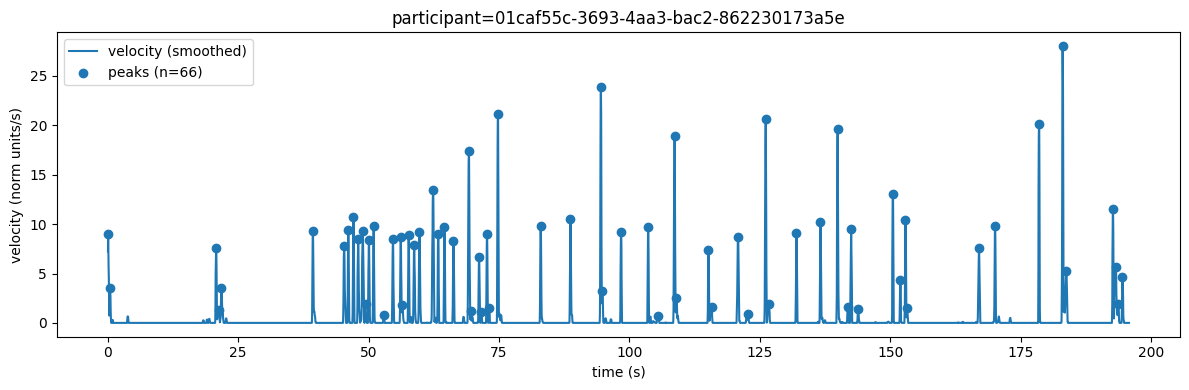

participant=01f97700-9c92-4464-9bf8-21132acaa881 | peaks=39 | dt_med≈48.00 ms | min_dist=200 ms (~4 samples)


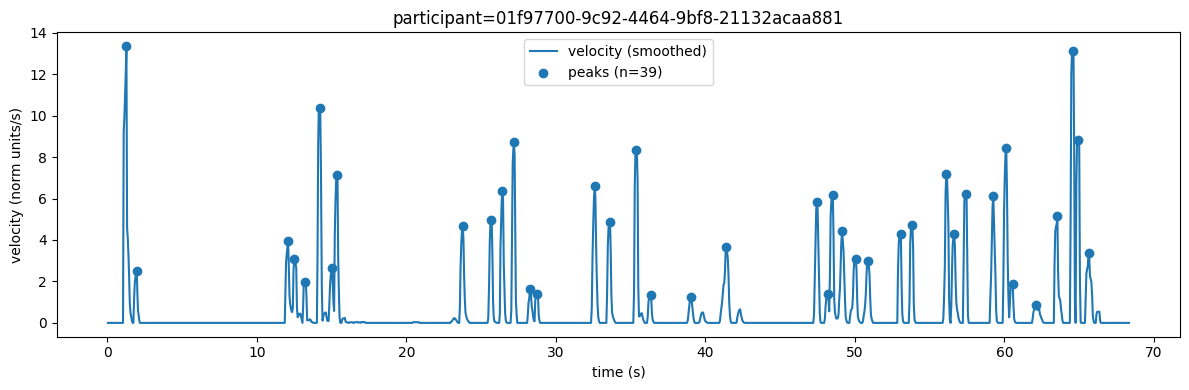

participant=05bcca80-e838-4ef3-8ba8-39e870310e8f | peaks=10 | dt_med≈40.00 ms | min_dist=200 ms (~5 samples)


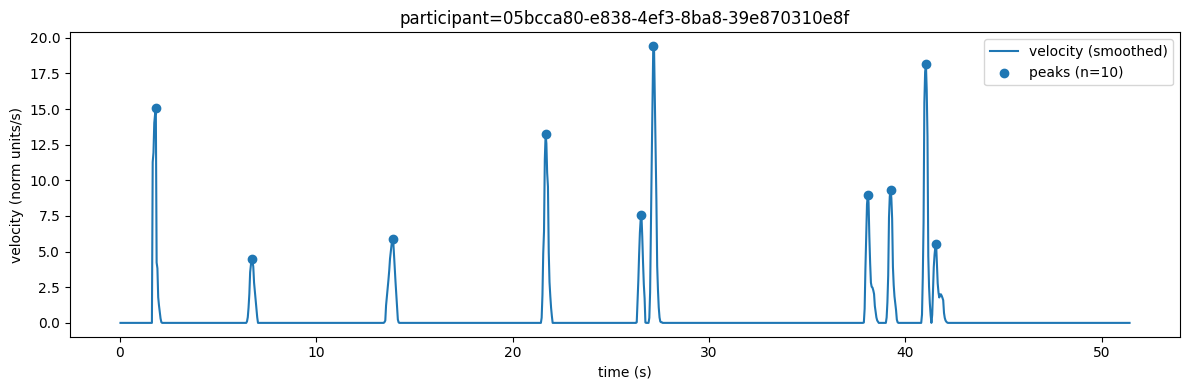

participant=0c8e7770-1c3e-40d4-af3e-561d63ec9aa3 | peaks=22 | dt_med≈41.00 ms | min_dist=200 ms (~5 samples)


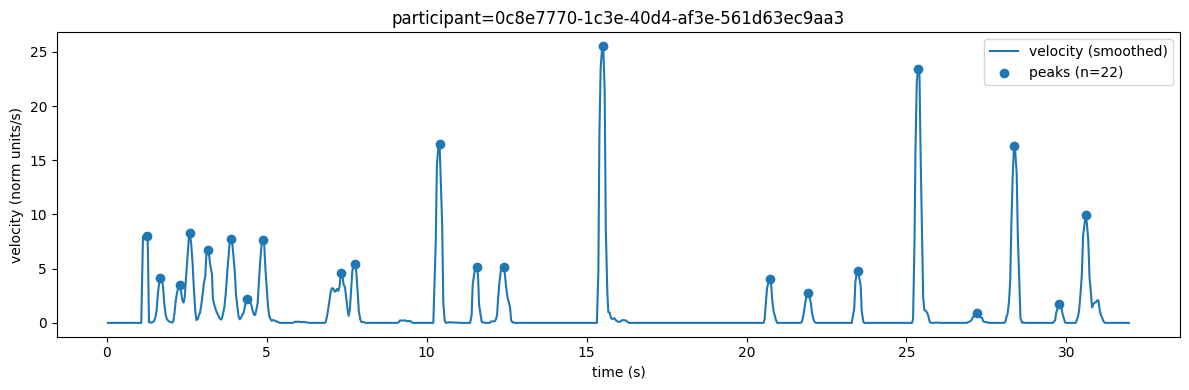

In [10]:
# 1) HYPERPARAMETER 

ROLL_WIN_SAMPLES        = 5    # 3-5
MIN_PEAK_HEIGHT_NORM_S  = 0.6  # in normalized units
MIN_PROMINENCE_NORM_S   = 0.7  # in normalized units
MIN_PEAK_DISTANCE_MS    = 200

# Use the dataframe that already contains dx/dy/dist/velocity (from compute_velocity_from_df)
DF_PLOT = events_with_steps 

# Which participants to plot:
PIDS = [
    DF_PLOT["participant_id"].iloc[0],
    "01f97700-9c92-4464-9bf8-21132acaa881",
    "05bcca80-e838-4ef3-8ba8-39e870310e8f",
    "0c8e7770-1c3e-40d4-af3e-561d63ec9aa3",
]


# 2) Helper functions

def moving_avg(a: np.ndarray, win: int) -> np.ndarray:
    if win <= 1:
        return a
    return (pd.Series(a, dtype="float64")
            .rolling(win, center=True, min_periods=1)
            .mean()
            .to_numpy())

def detect_peaks_for_group(
    g: pd.DataFrame,
    roll_win_samples: int,
    min_height_norm_s: float,
    min_prominence_norm_s: float,
    min_peak_distance_ms: float,
    x_col: str = "x_norm",
    y_col: str = "y_norm",
    velocity_col: str = "velocity_norm_s",  # reuse if present
):
    g = g.sort_values("t_ms").reset_index(drop=True)

    t_ms = pd.to_numeric(g["t_ms"], errors="coerce").to_numpy(float)
    x    = pd.to_numeric(g[x_col], errors="coerce").to_numpy(float)
    y    = pd.to_numeric(g[y_col], errors="coerce").to_numpy(float)

    # velocity (reuse if already computed)
    if velocity_col in g.columns and g[velocity_col].notna().any():
        v = pd.to_numeric(g[velocity_col], errors="coerce").to_numpy(float)
    else:
        dx = np.diff(x, prepend=np.nan)
        dy = np.diff(y, prepend=np.nan)
        dt_s = np.diff(t_ms, prepend=np.nan) / 1000.0

        dist = np.sqrt(dx*dx + dy*dy)
        v = np.full(len(g), np.nan)
        ok = np.isfinite(dt_s) & (dt_s > 0)
        v[ok] = dist[ok] / dt_s[ok]

    # smooth
    v_s = moving_avg(v, roll_win_samples)
    v_clean = np.where(np.isfinite(v_s), v_s, -np.inf)

    # ms -> samples (median dt)
    dt_med = np.nanmedian(np.diff(t_ms)) if len(t_ms) > 1 else np.nan
    if not np.isfinite(dt_med) or dt_med <= 0:
        dt_med = 1.0
    min_dist_samples = max(int(round(min_peak_distance_ms / dt_med)), 1)

    peaks, props = find_peaks(
        v_clean,
        height=min_height_norm_s,
        prominence=min_prominence_norm_s,
        distance=min_dist_samples
    )

    return (t_ms / 1000.0), v, v_s, peaks, props, dt_med, min_dist_samples

def plot_velocity_with_peaks(
    df_plot: pd.DataFrame, pid: str,
    roll_win_samples: int,
    min_height_norm_s: float,
    min_prominence_norm_s: float,
    min_peak_distance_ms: float,
    x_col: str = "x_norm",
    y_col: str = "y_norm",
    velocity_col: str = "velocity_norm_s",
):
    g = df_plot[df_plot["participant_id"] == pid].copy()
    if len(g) == 0:
        print(f"[SKIP] participant_id not found: {pid}")
        return

    t_s, v_raw, v_s, peaks, props, dt_med, min_dist_samples = detect_peaks_for_group(
        g,
        roll_win_samples=roll_win_samples,
        min_height_norm_s=min_height_norm_s,
        min_prominence_norm_s=min_prominence_norm_s,
        min_peak_distance_ms=min_peak_distance_ms,
        x_col=x_col,
        y_col=y_col,
        velocity_col=velocity_col
    )

    print(
        f"participant={pid} | peaks={len(peaks)} | "
        f"dt_med≈{dt_med:.2f} ms | min_dist={min_peak_distance_ms} ms (~{min_dist_samples} samples)"
    )

    plt.figure(figsize=(12, 4))
    plt.plot(t_s, v_s, label="velocity (smoothed)")
    if len(peaks):
        plt.scatter(t_s[peaks], v_s[peaks], label=f"peaks (n={len(peaks)})")
    plt.xlabel("time (s)")
    plt.ylabel("velocity (norm units/s)")
    plt.title(f"participant={pid}")
    plt.legend()
    plt.tight_layout()
    plt.show()


# 3) Run: loop over participants

for pid in PIDS:
    plot_velocity_with_peaks(
        DF_PLOT, pid,
        roll_win_samples=ROLL_WIN_SAMPLES,
        min_height_norm_s=MIN_PEAK_HEIGHT_NORM_S,
        min_prominence_norm_s=MIN_PROMINENCE_NORM_S,
        min_peak_distance_ms=MIN_PEAK_DISTANCE_MS,
        x_col="x_norm",
        y_col="y_norm",
        velocity_col="velocity_norm_s"
    )


## Hover Time

In [11]:
# Validate required columns
required = {"participant_id", "t_enter_ms", "t_leave_ms", "duration_ms"}
missing = required - set(hovers.columns)
if missing:
    raise ValueError(f"Missing required columns: {', '.join(sorted(missing))}")

# Ensure numeric types
for col in ["t_enter_ms", "t_leave_ms"]:
    hovers[col] = pd.to_numeric(hovers[col], errors="coerce")


#  Data Cleaning: keep valid, positive hover times and non-empty participant_id
hovers = hovers.loc[
    hovers["participant_id"].notna()
    & np.isfinite(hovers["duration_ms"])
    & (hovers["duration_ms"] > 0)
].copy()


# Aggregate per participant
metrics = (
    hovers.groupby("participant_id")["duration_ms"]
      .agg(total_hovertime_ms="sum",
           n_hovers="count",
           mean_hovertime_ms="mean",
           median_hovertime_ms="median",
           sd_hovertime_ms="std")      
      .reset_index()
)

# Replace NaN std with 0 for users with a single hover
metrics["sd_hovertime_ms"] = metrics["sd_hovertime_ms"].fillna(0.0)

# Calculate hovertime in seconds
metrics["total_hovertime_s"]  = metrics["total_hovertime_ms"]  / 1000.0
metrics["mean_hovertime_s"]   = metrics["mean_hovertime_ms"]   / 1000.0
metrics["median_hovertime_s"] = metrics["median_hovertime_ms"] / 1000.0
metrics["sd_hovertime_s"]    = metrics["sd_hovertime_ms"]    / 1000.0


# Print
display(metrics.head(10))

,participant_id,total_hovertime_ms,n_hovers,mean_hovertime_ms,median_hovertime_ms,sd_hovertime_ms,total_hovertime_s,mean_hovertime_s,median_hovertime_s,sd_hovertime_s
0,01caf55c-3693-4aa3-bac2-862230173a5e,170272,57,2987.228070,1556.0,3643.946668,170.272,2.987228,1.5560,3.643947
1,01f97700-9c92-4464-9bf8-21132acaa881,63215,28,2257.678571,938.0,3138.035869,63.215,2.257679,0.9380,3.138036
2,05bcca80-e838-4ef3-8ba8-39e870310e8f,35579,12,2964.916667,1225.0,3749.400787,35.579,2.964917,1.2250,3.749401
3,09836b97-00f6-47f3-b9aa-c34ad5867121,45903,18,2550.166667,995.0,5253.010411,45.903,2.550167,0.9950,5.253010
4,0c8e7770-1c3e-40d4-af3e-561d63ec9aa3,29332,17,1725.411765,1878.0,1376.977535,29.332,1.725412,1.8780,1.376978
5,10bcc14f-7fd9-4646-80bc-7eff4d2e1097,6927,15,461.800000,217.0,522.202369,6.927,0.461800,0.2170,0.522202
6,10e43c6b-430c-47be-8c7e-acfe0fe439b5,27442,10,2744.200000,483.5,5095.110026,27.442,2.744200,0.4835,5.095110
7,125fe34e-d1f0-498a-8fd0-5d0cf21e030d,25496,17,1499.764706,809.0,1914.712398,25.496,1.499765,0.8090,1.914712
8,15b9dd42-a1f4-43d2-a040-9bfa65d63082,65023,14,4644.500000,2881.5,4112.814285,65.023,4.644500,2.8815,4.112814
9,1826a545-f6f3-47b9-a091-81477ba89250,48314,18,2684.111111,894.0,5498.613589,48.314,2.684111,0.8940,5.498614


In [12]:
# Save hover metrics to CSV
hover_metrics_path = "/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/hover_metrics.csv" 
metrics.to_csv(hover_metrics_path, index=False)

print(f"Saved hover metrics to: {hover_metrics_path}")


Saved hover metrics to: /Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/hover_metrics.csv
